<a href="https://colab.research.google.com/github/eesa3372/Cheminformatics-Learning/blob/main/CheminformaticsLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy==1.26.4 --force-reinstall
!pip install rdkit scikit-learn

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires nu

In [ ]:
!pip install numpy==1.26.4

In [ ]:
import pandas as pd

data = {
    "Compound_Name": ["Ethanol", "Aspirin", "Methanol"],
    "Molecular_Weight_g": [46.07, 180.16, 32.04]
}

df = pd.DataFrame(data)

# CHALLENGE: Create a new column named 'Molecular_Weight_mg'
# by multiplying the 'Molecular_Weight_g' column by 1000
df["Molecular_Weight_mg"] = df["Molecular_Weight_g"] *1000

print(df)
from rdkit import Chem

# 1. Load Ethanol (CCO)
mol = Chem.MolFromSmiles("CCO")

# 2. Count the atoms (Note: By default, RDKit counts heavy atoms like Carbon and Oxygen, ignoring Hydrogens)
atom_count = mol.GetNumAtoms()

print(f"Number of heavy atoms: {atom_count}")

In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors

In [ ]:
# 1. Create a dictionary with some common molecules and their SMILES strings
data = {
    'Molecule_Name': ['Ethanol', 'Aspirin', 'Caffeine'],
    'SMILES': ['CCO', 'CC(=O)OC1=CC=CC=C1C(=O)O', 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C']
}

# 2. Load the data into a Pandas DataFrame
df = pd.DataFrame(data)

# 3. Use RDKit to convert SMILES strings into RDKit Molecule Objects
df['Mol_Object'] = df['SMILES'].apply(Chem.MolFromSmiles)

# 4. Calculate Molecular Weight for each molecule using RDKit Descriptors
df['Molecular_Weight'] = df['Mol_Object'].apply(Descriptors.ExactMolWt)

# Display the DataFrame
df

In [ ]:
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.ipython_useSVG = True  # Uses crisp SVG images instead of PNG# Create a list of the molecule objects and their names for the legend
mols = df['Mol_Object'].tolist()
legends = df['Molecule_Name'].tolist()

# Draw the molecules in a grid
Draw.MolsToGridImage(mols, legends=legends, molsPerRow=3)

In [ ]:
df = pd.read_csv('sample_data/california_housing_train.csv')

In [ ]:
display(df)

In [ ]:
from rdkit import Chem

# 1. Load Ethanol (CCO)
mol = Chem.MolFromSmiles("CCO")

# 2. Count the atoms (Note: By default, RDKit counts heavy atoms like Carbon and Oxygen, ignoring Hydrogens)
atom_count = mol.GetNumAtoms()

print(f"Number of heavy atoms: {atom_count}")

In [ ]:
from rdkit import Chem

# A typo'd SMILES string that doesn't make chemical sense
broken_smiles = "C==C==C==C==C"

mol = Chem.MolFromSmiles(broken_smiles)

# CHALLENGE: Check if RDKit successfully created the molecule
# or if it returned None.
if mol is None:
    print("Error: This SMILES string is invalid!")
else:
    print(f"Success! This molecule has {mol.GetNumAtoms()} atoms.")

In [ ]:
from rdkit import Chem

# A completely broken, chemically impossible SMILES string
invalid_smiles = "C1CC1CC(C)CC(C)C1"

# RDKit tries to read it
mol = Chem.MolFromSmiles(invalid_smiles)

# The Industry-Standard Guard Check
if mol is None:
    print("Error: This SMILES string is invalid!")
else:
    print(f"Success! The molecule has {mol.GetNumAtoms()} atoms.")

In [ ]:
from rdkit import Chem

smiles_list = [
    "CCO",  # Ethanol (valid)
    "CC(=O)OC1=CC=CC=C1C(=O)O", # Aspirin (valid)
    "C1CC1CC(C)CC(C)C1", # Invalid SMILES (as discussed previously)
    "CCCCC", # Pentane (valid)
    "C=1CCCC1", # Invalid ring closure
    "c1ccccc1", # Benzene (valid)
    "invalid_string" # Completely invalid
]

validated_smiles = []

for i, smiles in enumerate(smiles_list):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f"SMILES string {i+1}: '{smiles}' is INVALID")
    else:
        print(f"SMILES string {i+1}: '{smiles}' is VALID (Num Atoms: {mol.GetNumHeavyAtoms()})")
        validated_smiles.append({'SMILES': smiles, 'Mol': mol})

print("\nValidated SMILES objects stored in 'validated_smiles' list.")

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

# 1. Load Aspirin from SMILES
aspirin_mol = Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O")

# 2. Save the molecule structure as a PNG file image!
Draw.MolToFile(aspirin_mol, "aspirin.png")

In [ ]:
from IPython.display import Image
Image('aspirin.png')

In [ ]:
from rdkit import Chem

# 1. Create our search pattern (Benzene ring)
pattern = Chem.MolFromSmiles("c1ccccc1")

# 2. Load the molecule we want to inspect (Aspirin)
aspirin = Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O")

# CHALLENGE: Call the substructure match function on aspirin,
# passing our search 'pattern' inside the parentheses!
has_ring = aspirin.HasSubstructMatch(pattern)

if has_ring:
    print("Match found! This molecule contains a Benzene ring.")
else:
    print("No match found.")

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors

# Load a molecule (Aspirin)
mol = Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O")

# Calculate its exact molecular weight
exact_weight = Descriptors.MolWt(mol)

print(f"The exact molecular weight is: {exact_weight}")

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors

# 1. Load Caffeine
caffeine_mol = Chem.MolFromSmiles("CN1C=NC2=C1C(=O)N(C(=O)N2C)C")

# CHALLENGE: Call the correct function from the Descriptors module
# to find the molecular weight of caffeine_mol
caffeine_weight = Descriptors.MolWt(caffeine_mol)

print(f"Caffeine's molecular weight is: {caffeine_weight}")

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors

# 1. Load Aspirin
aspirin_mol = Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O")

# 2. Calculate the properties
weight = Descriptors.MolWt(aspirin_mol)
logp = Descriptors.MolLogP(aspirin_mol) # Blank 1: Get LogP

# 3. Screen the molecule using an if statement
if weight < 500.0 and logp < 5.0: # Blank 2: Link conditions with the Python 'and' keyword
    print("Pass! This molecule fits the criteria.")
else: # Blank 3: What fallback handles failure?
    print("Fail: Molecule violates the criteria.")

In [ ]:
import pandas as pd
from rdkit import Chem

data = {
    "Compound_Name": ["Ethanol", "Methanol", "Aspirin"],
    "SMILES": ["CCO", "CO", "CC(=O)OC1=CC=CC=C1C(=O)O"]
}
df = pd.DataFrame(data)

# Use a loop inside a list (list comprehension) to convert the entire SMILES column into RDKit objects!
df["Mol_Object"] = [Chem.MolFromSmiles(s) for s in df["SMILES"]]

print(df)

In [ ]:
import pandas as pd
from rdkit import Chem

data = {
    "Compound_Name": ["Ethanol", "Methanol", "Aspirin"],
    "SMILES": ["CCO", "CO", "CC(=O)OC1=CC=CC=C1C(=O)O"]
}
df = pd.DataFrame(data)

# 1. Turn SMILES into RDKit Objects
df["Mol_Object"] = [Chem.MolFromSmiles(s) for s in df["SMILES"]]

# CHALLENGE: Complete the list comprehension to call .GetNumAtoms()
# on every 'm' (molecule object) inside our new df["Mol_Object"] column!
df["Heavy_Atom_Count"] = [m.GetNumAtoms() for m in df["Mol_Object"]]

print(df[["Compound_Name", "Heavy_Atom_Count"]])

In [ ]:
from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator # Import GetMorganGenerator

# 1. Load a molecule
mol = Chem.MolFromSmiles("CCO") # Ethanol

# 2. Generate a Morgan Fingerprint using GetMorganGenerator
# radius=2 mimics the industry standard ECFP4. nBits=1024 is the length of our binary array.
gen = GetMorganGenerator(radius=2, fpSize=1024)
fp = gen.GetFingerprint(mol)

# 3. Convert it to a visible list of 0s and 1s
bit_list = list(fp)

# Let's see how many bits were turned "on" (1) by the structure of Ethanol
print(f"Total bits: {len(bit_list)}")
print(f"Number of active bits: {bit_list.count(1)}")

When generating a Morgan Fingerprint (which is a type of Extended Connectivity Fingerprint, or ECFP):

*   **`radius=2`**: This parameter determines how many bonds away from each atom RDKit will look to define the environment for that atom. A `radius=2` is commonly used and is analogous to **ECFP4** (Extended Connectivity Fingerprint with a diameter of 4 bonds, i.e., radius of 2).

    *   **Radius 0**: Considers only the atom itself and its immediate bonds (like atom type and degree).
    *   **Radius 1**: Considers the atom, its immediate neighbors, and the connections between them.
    *   **Radius 2**: Extends this to include atoms two bonds away from the central atom.

    A larger radius captures more structural information but also makes the fingerprint longer and potentially less specific to certain substructures.

*   **`nBits=1024`**: This specifies the length of the binary fingerprint vector (the array of 0s and 1s). A fingerprint is generated by hashing the chemical environments found in the molecule into specific positions (bits) in this fixed-length vector. If a particular environment is present, the corresponding bit is set to 1; otherwise, it remains 0.

    *   A larger `nBits` reduces the chance of **collisions** (different chemical environments mapping to the same bit position), which can lead to a more unique representation of the molecule.
    *   `1024` is a common choice, providing a balance between specificity and computational efficiency. Other common values include 2048 or 4096.

In [ ]:
from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator # Import GetMorganGenerator
from rdkit import DataStructs # The module containing similarity metrics

# 1. Load two similar molecules
mol1 = Chem.MolFromSmiles("CO")  # Methanol
mol2 = Chem.MolFromSmiles("CCO") # Ethanol

# 2. Generate fingerprints for both using GetMorganGenerator
gen = GetMorganGenerator(radius=2, fpSize=1024)
fp1 = gen.GetFingerprint(mol1)
fp2 = gen.GetFingerprint(mol2)

# CHALLENGE: Call the Tanimoto similarity function from DataStructs
# to compare fp1 and fp2
similarity = DataStructs.TanimotoSimilarity(fp1, fp2)

print(f"The structural similarity score is: {similarity:.2f}")

In [ ]:
from rdkit import Chem

# 1. Define our structural search query (Carboxylic Acid SMARTS)
acid_pattern = Chem.MolFromSmarts("C(=O)[O;H1]")

# 2. Load Aspirin (which has a carboxylic acid group)
aspirin = Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O")

# 3. Check for a match
has_acid = aspirin.HasSubstructMatch(acid_pattern)
print(f"Contains carboxylic acid: {has_acid}")

In [ ]:
from rdkit import Chem

# 1. Define the alert pattern for an reactive Acyl Chloride
alert_pattern = Chem.MolFromSmarts("C(=O)Cl")

# 2. Load a test compound molecule string
test_compound = Chem.MolFromSmiles("CC(=O)Cl") # Acetyl chloride

# CHALLENGE: Check if the test compound contains the toxic alert pattern
is_reactive = test_compound.HasSubstructMatch(alert_pattern)

if is_reactive:
    print("ALERT: This molecule contains an unstable group! Discard it.")
else:
    print("Safe! No structural alerts found.")

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

# 1. Setup our target and pattern
test_compound = Chem.MolFromSmiles("CC(=O)Cl")
alert_pattern = Chem.MolFromSmarts("C(=O)Cl")

# 2. Get the exact atom indices where the pattern matches
matching_atoms = test_compound.GetSubstructMatch(alert_pattern)

# Let's see what indices RDKit found (it will be a tuple of numbers like (1, 2, 3))
print(f"The structural alert matches atom indices: {matching_atoms}")

# 3. Draw the molecule with the alert highlighted in red!
Draw.MolToImage(test_compound, highlightAtoms=matching_atoms, highlightAtomColors={atom_index: (255, 0, 0) for atom_index in matching_atoms})

In [ ]:
import pandas as pd
from rdkit import Chem

# A sample library of molecules we want to screen
data = {
    "Drug_Name": ["Aspirin", "Reactive_Toxin_X", "Ibuprofen"],
    "SMILES": ["CC(=O)OC1=CC=CC=C1C(=O)O", "CC(=O)Cl", "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O"]
}
df = pd.DataFrame(data)
df["Mol_Object"] = [Chem.MolFromSmiles(s) for s in df["SMILES"]]

# Define the alert pattern we want to clean out
alert_pattern = Chem.MolFromSmarts("C(=O)Cl")

# CHALLENGE: Write the list comprehension loop to call .HasSubstructMatch(alert_pattern)
# on every single molecule object 'm' in our df["Mol_Object"] column!
df["Is_Toxic"] = [m.HasSubstructMatch(alert_pattern) for m in df["Mol_Object"]]

# Print the final screening report
print(df[["Drug_Name", "Is_Toxic"]])
# Keep only the safe molecules where Is_Toxic is False
clean_df = df[df["Is_Toxic"] == False]

print("--- Cleaned Chemical Library ---")
print(clean_df[["Drug_Name", "SMILES"]])

In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator # Import GetMorganGenerator

# 1. Create a dataset of 6 compounds with a known "Activity" label (1 = Drug Works, 0 = Fails)
data = {
    "Compound": ["Methanol", "Ethanol", "Aspirin", "Ibuprofen", "Toxin_A", "Toxin_B"],
    "SMILES": ["CO", "CCO", "CC(=O)OC1=CC=CC=C1C(=O)O", "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O", "CC(=O)Cl", "CC(=O)Br"],
    "Activity": [0, 0, 1, 1, 0, 0]
}
df = pd.DataFrame(data)

# 2. Convert SMILES to RDKit Objects
df["Mol_Object"] = [Chem.MolFromSmiles(s) for s in df["SMILES"]]

# Removed: print("Dataset Loaded Successfully!")

# 1. Generate Morgan Fingerprints as bit vectors using GetMorganGenerator
gen = GetMorganGenerator(radius=2, fpSize=1024)
fingerprints = [gen.GetFingerprint(m) for m in df["Mol_Object"]]

# 2. Convert the RDKit bit vectors into standard Python lists of numbers (0s and 1s)
X = np.array([list(fp) for fp in fingerprints])

# 3. Extract our target labels (Activity)
y = df["Activity"].values

print(f"Feature Matrix (X) Shape: {X.shape}") # Outputs (6, 1024) -> 6 molecules, 1024 features each
# Removed: print(f"Target Vector (y) Shape: {y.shape}")

from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Random Forest model with 100 decision trees
model = RandomForestClassifier(n_estimators=100, random_state=42)

# CHALLENGE: Train the machine learning model using your features (X) and targets (y)
model.fit(X, y)

print("Model training complete!")
# 1. Load the new molecule (Paracetamol)
new_mol = Chem.MolFromSmiles("CC(=O)NC1=CC=C(O)C=C1")

# 2. Use your modern generator to create its fingerprint vector
new_fp = gen.GetFingerprint(new_mol)
new_X = np.array([list(new_fp)]) # Reshape into a 2D matrix layout for scikit-learn

# 3. Make the prediction!
prediction = model.predict(new_X)
probability = model.predict_proba(new_X)

print(f"Predicted Class: {prediction[0]}")
print(f"Probability Profile [Inactive, Active]: {probability[0]}")
# Look inside the trained model's brain
# CHALLENGE: Fetch the array of feature weights from the model attribute
importances = model.feature_importances_

# Let's find the bit index that held the absolute highest importance
most_important_bit = np.argmax(importances)
print(f"The structural feature at bit index {most_important_bit} was the key driver for predictions!")

In [ ]:
!pip list

In [ ]:
from rdkit.Chem import Draw

# 1. Re-run fingerprinting, but this time save the atom mapping details
ao = AllChem.AdditionalOutput()
ao.AllocateBitInfoMap()
fp = gen.GetFingerprint(df["Mol_Object"][2], additionalOutput=ao) # Using Aspirin as an example

# 2. Extract the map of which atom indices caused which bit to turn on
bit_info = ao.GetBitInfoMap()

# 3. Check if our most important bit was present in Aspirin
if most_important_bit in bit_info:
    # Get the central atom and radius for that specific bit fragment
    atom_id, radius = bit_info[most_important_bit][0]

    # Draw just that small sub-fragment so a human chemist can see it!
    img = Draw.DrawMorganBit(df["Mol_Object"][2], most_important_bit, bit_info)
    display(img)
else:
    print(f"Bit {most_important_bit} wasn't found in Aspirin, it belongs to one of the other molecules!")

In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from sklearn.ensemble import RandomForestClassifier

Now that the libraries are re-imported, please proceed to re-run the `RandomForest` training cell (cell `ZxgJ1v5FkOEW`) to confirm if the `numpy` compatibility error has been resolved with the downgraded version.

In [ ]:
!pip install chembl_webresource_client

from chembl_webresource_client.new_client import new_client
import pandas as pd

# 1. Search for a biological target (e.g., Human Coronavirus)
target = new_client.target
target_query = target.search('coronavirus')
targets = pd.DataFrame.from_dict(target_query)

# Let's view the target options available in the database
print(targets[['target_chembl_id', 'pref_name']].head())

In [ ]:
!pip install chembl_webresource_client

from chembl_webresource_client.new_client import new_client
import pandas as pd

# 1. Search for a biological target (e.g., Human Coronavirus)
target = new_client.target
target_query = target.search('coronavirus')
targets = pd.DataFrame.from_dict(target_query)

# Let's view the target options available in the database
print(targets[['target_chembl_id', 'pref_name']].head())

In [ ]:
!pip install chembl_webresource_client

import pandas as pd
from chembl_webresource_client.new_client import new_client

print("ChEMBL Client Loaded Successfully!")

In [ ]:
from chembl_webresource_client.new_client import new_client
import pandas as pd

# Initialize the target API resource
target_api = new_client.target

# Search for the protein by name
search_results = target_api.search('acetylcholinesterase')
target_df = pd.DataFrame.from_dict(search_results)

# Let's pull the human version specifically
human_target = target_df[target_df['organism'] == 'Homo sapiens']
print(human_target[['target_chembl_id', 'pref_name', 'organism']].head(1))

In [ ]:
!pip install chembl_webresource_client

import pandas as pd
from chembl_webresource_client.new_client import new_client

print("ChEMBL Client Loaded Successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.5 MB/s eta 0:00:00
ChEMBL Client Loaded Successfully!


In [ ]:
# Initialize the target API resource
target_api = new_client.target

# Search for the protein by name
search_results = target_api.search('acetylcholinesterase')
target_df = pd.DataFrame.from_dict(search_results)

# Let's pull the human version specifically
human_target = target_df[target_df['organism'] == 'Homo sapiens']
print(human_target[['target_chembl_id', 'pref_name', 'organism']].head(1))

  target_chembl_id             pref_name      organism
1        CHEMBL220  Acetylcholinesterase  Homo sapiens


In [ ]:
activity_api = new_client.activity

# CHALLENGE: Call the .filter() method on activity_api using the target ID,
# standard_type='IC50', and standard_units='nM'
res = activity_api.filter(
    target_chembl_id="CHEMBL220",
    standard_type="IC50",
    standard_units="nM"
)

# Convert the raw API response directly into a Pandas DataFrame
df = pd.DataFrame.from_dict(res)

print(f"Data retrieved! Spreadsheet contains {len(df)} bioactivity records.")
print(df[['molecule_chembl_id', 'canonical_smiles', 'standard_value']].head())

Data retrieved! Spreadsheet contains 8395 bioactivity records.
  molecule_chembl_id                                   canonical_smiles  \
0       CHEMBL133897              CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1   
1       CHEMBL336398         O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1   
2       CHEMBL131588  CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1   
3       CHEMBL130628      O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F   
4       CHEMBL130478          CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C   

  standard_value  
0          750.0  
1          100.0  
2        50000.0  
3          300.0  
4          800.0  


In [ ]:
# 1. Drop rows that don't have a valid SMILES string or a measurement value
clean_df = df.dropna(subset=['canonical_smiles', 'standard_value']).copy()

# 2. Convert the IC50 values from text strings to actual numbers
clean_df['standard_value'] = pd.to_numeric(clean_df['standard_value'])

# 3. Keep only the essential columns we need for molecular modeling
final_df = clean_df[['molecule_chembl_id', 'canonical_smiles', 'standard_value']]

print(f"Cleaned dataset shape: {final_df.shape}")
print(final_df.head())

Cleaned dataset shape: (8372, 3)
  molecule_chembl_id                                   canonical_smiles  \
0       CHEMBL133897              CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1   
1       CHEMBL336398         O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1   
2       CHEMBL131588  CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1   
3       CHEMBL130628      O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F   
4       CHEMBL130478          CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C   

   standard_value  
0           750.0  
1           100.0  
2         50000.0  
3           300.0  
4           800.0  


In [ ]:
import numpy as np

# 1. Clean the dataset: ensure values are numbers and drop missing rows
clean_df['standard_value'] = pd.to_numeric(clean_df['standard_value'], errors='coerce')
clean_df = clean_df.dropna(subset=['canonical_smiles', 'standard_value'])

# 2. Filter out any problematic zero entries to protect our logarithm
clean_df = clean_df[clean_df['standard_value'] > 0]

# 3. Define the professional pIC50 conversion function
def convert_to_pic50(ic50_val):
    # Convert nanomolar to molar by dividing by 10^9, then take negative log10
    molar_val = ic50_val / 1e9
    pic50 = -np.log10(molar_val)
    return pic50

# 4. Apply the function to create our clean target column (y)
clean_df['pIC50'] = clean_df['standard_value'].apply(convert_to_pic50)

print("Transformation Complete!")
print(clean_df[['molecule_chembl_id', 'standard_value', 'pIC50']].head())

Transformation Complete!
  molecule_chembl_id  standard_value     pIC50
0       CHEMBL133897           750.0  6.124939
1       CHEMBL336398           100.0  7.000000
2       CHEMBL131588         50000.0  4.301030
3       CHEMBL130628           300.0  6.522879
4       CHEMBL130478           800.0  6.096910


In [ ]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict

print("Synchronizing data and extracting scaffolds...")

# 1. Reset index first to ensure positional indexing (0 to N-1) matches our loops
clean_df = clean_df.reset_index(drop=True)

# 2. Convert SMILES to RDKit Mol objects
clean_df['Mol_Object'] = [Chem.MolFromSmiles(s) for s in clean_df['canonical_smiles']]

# 3. Function to extract the core Murcko scaffold
def get_scaffold(mol):
    try:
        scaffold_mol = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold_mol)
    except:
        return ""

# 4. Apply and group indices
clean_df['Scaffold_SMILES'] = clean_df['Mol_Object'].apply(get_scaffold)

scaffold_to_indices = defaultdict(list)
for idx, scaffold in enumerate(clean_df['Scaffold_SMILES']):
    scaffold_to_indices[scaffold].append(idx)

print(f"Success: Identified {len(scaffold_to_indices)} scaffolds for {len(clean_df)} compounds.")

Synchronizing data and extracting scaffolds...
Success: Identified 2827 scaffolds for 8371 compounds.


In [ ]:
import random

# 1. Sort scaffolds by size
sorted_scaffolds = sorted(scaffold_to_indices.items(), key=lambda x: len(x[1]), reverse=True)

train_indices = []
test_indices = []
max_test_size = int(len(clean_df) * 0.20)

# 2. Distribute indices based on scaffold families
for scaffold, indices in sorted_scaffolds:
    if len(test_indices) + len(indices) <= max_test_size:
        test_indices.extend(indices)
    else:
        train_indices.extend(indices)

# 3. Create the split dataframes from clean_df (which contains pIC50)
train_df = clean_df.iloc[train_indices].copy()
test_df = clean_df.iloc[test_indices].copy()

print(f"--- Scaffold Split Complete ---")
print(f"Training Dataset Size: {len(train_df)} compounds")
print(f"Testing Dataset Size:  {len(test_df)} compounds")

# Quick verification to prevent KeyError in the next step
if 'pIC50' in train_df.columns:
    print("Success: 'pIC50' column is present in the split datasets.")
else:
    print("Warning: 'pIC50' column is still missing. Please ensure cell NUFoxMn-seZK was run.")

--- Scaffold Split Complete ---
Training Dataset Size: 6697 compounds
Testing Dataset Size:  1674 compounds
Success: 'pIC50' column is present in the split datasets.


In [ ]:
import numpy as np
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

# 1. Initialize your future-proof fingerprint generator (Radius=2, 1024-bit array)
fp_size = 1024
gen = GetMorganGenerator(radius=2, fpSize=fp_size)

# Helper function to convert a column of RDKit molecule objects into a fast NumPy matrix
def featurize_dataset(df_column):
    # Pre-allocate a highly efficient, blank layout matrix of zeros
    matrix = np.zeros((len(df_column), fp_size), dtype=np.int8)

    for i, mol in enumerate(df_column):
        if mol is not None:
            # Generate the fingerprint bit vector
            fp = gen.GetFingerprint(mol)
            # Convert the ExplicitBitVect to a list and then to a NumPy array, then assign to the matrix row
            matrix[i] = np.array(list(fp), dtype=np.int8)

    return matrix

print("Vectorizing datasets using GetMorganGenerator...")

# 2. Extract the features (X) for both split fractions
X_train = featurize_dataset(train_df['Mol_Object'])
X_test = featurize_dataset(test_df['Mol_Object'])

# 3. Extract the clean logarithmic pIC50 target attributes (y)
# This will no longer throw a KeyError!
y_train = train_df['pIC50'].values
y_test = test_df['pIC50'].values

print("\n--- Featurization Process Complete ---")
print(f"X_train shape (Training Features): {X_train.shape}")
print(f"y_train shape (Training Targets):  {y_train.shape}")
print(f"X_test shape  (Testing Features):  {X_test.shape}")
print(f"y_test shape  (Testing Targets):   {y_test.shape}")

Vectorizing datasets using GetMorganGenerator...

--- Featurization Process Complete ---
X_train shape (Training Features): (6697, 1024)
y_train shape (Training Targets):  (6697,)
X_test shape  (Testing Features):  (1674, 1024)
y_test shape  (Testing Targets):   (1674,)


Training Random Forest model on scaffold-split data...

--- Model Performance ---
R^2 Score: 0.313
Mean Squared Error: 1.543


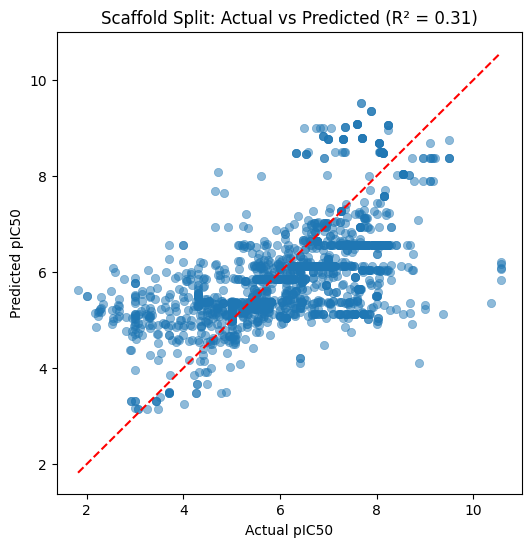

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize and train the Random Forest Regressor
print("Training Random Forest model on scaffold-split data...")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 2. Make predictions on the test set
y_pred = model.predict(X_test)

# 3. Calculate performance metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"\n--- Model Performance ---")
print(f"R^2 Score: {r2:.3f}")
print(f"Mean Squared Error: {mse:.3f}")

# 4. Visualize the results
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, edgecolor=None)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--') # Identity line
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")
plt.title(f"Scaffold Split: Actual vs Predicted (R² = {r2:.2f})")
plt.show()

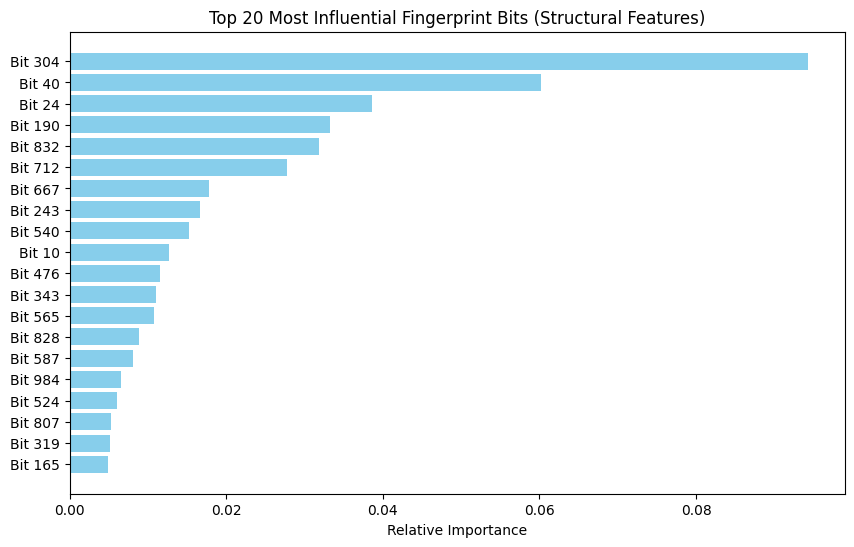

The most important structural feature is Bit 304.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Get feature importances from the trained Random Forest
importances = model.feature_importances_
indices = np.argsort(importances)[-20:]  # Get the top 20 most important bits

# 2. Visualize the top features
plt.figure(figsize=(10, 6))
plt.title("Top 20 Most Influential Fingerprint Bits (Structural Features)")
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [f"Bit {i}" for i in indices])
plt.xlabel("Relative Importance")
plt.show()

print(f"The most important structural feature is Bit {indices[-1]}.")

Visualizing structural fragment for Bit 304 found in a training compound:


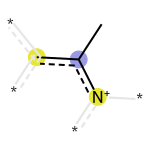

In [ ]:
from rdkit.Chem import Draw, AllChem

# 1. Identify a molecule in the training set that contains the most important bit (e.g., Bit 304)
target_bit = indices[-1]
sample_mol = None
bit_info_map = {}

# When using GetMorganGenerator, we use AdditionalOutput to capture bit info
for mol in train_df['Mol_Object']:
    if mol is not None:
        ao = AllChem.AdditionalOutput()
        ao.AllocateBitInfoMap()
        gen.GetFingerprint(mol, additionalOutput=ao)
        bi = ao.GetBitInfoMap()

        if target_bit in bi:
            sample_mol = mol
            bit_info_map = bi
            break

# 2. Visualize the fragment
if sample_mol:
    print(f"Visualizing structural fragment for Bit {target_bit} found in a training compound:")
    img = Draw.DrawMorganBit(sample_mol, target_bit, bit_info_map)
    display(img)
else:
    print(f"Bit {target_bit} was not found in the dataset molecules.")

In [ ]:
import numpy as np
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

# 1. Initialize your future-proof fingerprint generator (Radius=2, 1024-bit array)
fp_size = 1024
gen = GetMorganGenerator(radius=2, fpSize=fp_size)

# Helper function to convert a column of RDKit molecule objects into a fast NumPy matrix
def featurize_dataset(df_column):
    # Pre-allocate a highly efficient, blank layout matrix of zeros
    matrix = np.zeros((len(df_column), fp_size), dtype=np.int8)

    for i, mol in enumerate(df_column):
        if mol is not None:
            # Generate the fingerprint bit vector
            fp = gen.GetFingerprint(mol)
            # Convert the ExplicitBitVect to a list and then to a NumPy array, then assign to the matrix row
            matrix[i] = np.array(list(fp), dtype=np.int8)

    return matrix

print("Vectorizing datasets using GetMorganGenerator...")

# 2. Extract the features (X) for both split fractions
X_train = featurize_dataset(train_df['Mol_Object'])
X_test = featurize_dataset(test_df['Mol_Object'])

# 3. Extract the clean logarithmic pIC50 target attributes (y)
# This will no longer throw a KeyError!
y_train = train_df['pIC50'].values
y_test = test_df['pIC50'].values

print("\n--- Featurization Process Complete ---")
print(f"X_train shape (Training Features): {X_train.shape}")
print(f"y_train shape (Training Targets):  {y_train.shape}")
print(f"X_test shape  (Testing Features):  {X_test.shape}")
print(f"y_test shape  (Testing Targets):   {y_test.shape}")

Vectorizing datasets using GetMorganGenerator...

--- Featurization Process Complete ---
X_train shape (Training Features): (6697, 1024)
y_train shape (Training Targets):  (6697,)
X_test shape  (Testing Features):  (1674, 1024)
y_test shape  (Testing Targets):   (1674,)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Initialize the Regressor
# n_jobs=-1 tells Colab to use all available CPU cores to train faster!
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("🧠 Training the Random Forest model on 6,697 compounds. This may take 30-60 seconds...")

# 2. Fit the model to the training features and targets
model.fit(X_train, y_train)

# 3. Predict the pIC50 values for the 1,674 unseen Test compounds
print("🎯 Predicting pIC50 values for the 1,674 hidden scaffold test compounds...")
y_pred = model.predict(X_test)

# 4. Calculate performance metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n--- 🏆 Model Performance on Scaffold Test Set ---")
print(f"R-squared (R2): {r2:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f} log units")

🧠 Training the Random Forest model on 6,697 compounds. This may take 30-60 seconds...
🎯 Predicting pIC50 values for the 1,674 hidden scaffold test compounds...

--- 🏆 Model Performance on Scaffold Test Set ---
R-squared (R2): 0.313
Root Mean Squared Error (RMSE): 1.242 log units


In [28]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# 1. Define the "reaction conditions" we want to test
param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    # 'max_features' restricts how many bits each tree is allowed to look at
    'max_features': ['sqrt', 'log2', 0.2]
}

# 2. Set up the baseline model
rf = RandomForestRegressor(random_state=42)

# 3. Configure the Automated Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=15,    # Test 15 random combinations
    cv=3,         # 3-fold cross-validation
    scoring='r2',
    n_jobs=-1,    # Use all Colab CPUs for speed
    random_state=42,
    verbose=2
)

print("🔬 Starting Hyperparameter Optimization... this might take 2-3 minutes!")
random_search.fit(X_train, y_train)

# 4. Extract the winning model!
best_model = random_search.best_estimator_
print(f"\n🏆 Best Parameters Found:\n{random_search.best_params_}")

# 5. Re-test against our Scaffold Hold-out Set
print("\n🎯 Predicting on Scaffold Test Set with optimized model...")
y_pred_opt = best_model.predict(X_test)

r2_opt = r2_score(y_test, y_pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))

print(f"Old R-squared: 0.313 -> New R-squared: {r2_opt:.3f}")
print(f"Old RMSE: 1.242 -> New RMSE: {rmse_opt:.3f}")

🔬 Starting Hyperparameter Optimization... this might take 2-3 minutes!
Fitting 3 folds for each of 15 candidates, totalling 45 fits

🏆 Best Parameters Found:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}

🎯 Predicting on Scaffold Test Set with optimized model...
Old R-squared: 0.313 -> New R-squared: 0.356
Old RMSE: 1.242 -> New RMSE: 1.202
